# CLUSTERING ANALYSIS 

### Understanding and Implementing K-Means, Hierarchical, and DBSCAN Algorithms

### Objective:

### Datasets :

In [1]:
import pandas as pd
import numpy as np

### Data Preprocessing:

In [2]:
ls

 Volume in drive D has no label.
 Volume Serial Number is 4EEB-3B4E

 Directory of D:\shibu_DS\3\8_Clustering

22-03-2026  06.15 PM    <DIR>          .
22-03-2026  06.15 PM    <DIR>          ..
20-03-2026  09.40 AM    <DIR>          .ipynb_checkpoints
22-03-2026  06.15 PM           890,993 8_Clustering.ipynb
12-04-2024  12.26 PM            16,782 Clustering Analysis.docx
12-04-2024  12.26 PM           268,963 EastWestAirlines - Copy.xlsx
20-03-2026  10.02 AM           263,815 EastWestAirlines.xlsx
               4 File(s)      1,440,553 bytes
               3 Dir(s)  111,888,646,144 bytes free


In [3]:
df = pd.read_excel("EastWestAirlines.xlsx")
df.head(2)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [6]:
## The dataset contains 3999 observations and 12 numerical features. There are no missing values in the dataset.. 
## All the variables are numeric in nature. The column ID# represents a unique ID and does not contribute to clustering process..
## So ID# will be dropped before model building.. 

df = df.drop("ID#", axis = 1)
df.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [7]:
## From the summary statistics it can be seen that some variables such as Balance, Bonus_miles and Flight_miles_12mo contain some extreme values..
## It indicates the presence of outliers.. these values may affect the clustering performance..
## we will have to handel them appropriately as required..
## At the same time we need keep this in mind that in clustering we do not agrresively removes outliers, instead we do scaling ..
## also scaling is important here because some columns have values in lakhs and some have values between (1-5).. we need to bring them in similar scale..
## since there are no null values present in the given dataset  and all the column has numeric datatype so we can directly jump to scalling part..

In [8]:
## Scaling.. 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [9]:
print(scaled_data)

[[-4.51140783e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
   1.39545434e+00 -7.66919299e-01]
 [-5.39456874e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
   1.37995704e+00 -7.66919299e-01]
 [-3.20031232e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
   1.41192021e+00 -7.66919299e-01]
 ...
 [-4.29480975e-05 -1.86298687e-01  6.83121167e-01 ... -3.62167870e-01
  -1.31560393e+00  1.30391816e+00]
 [-1.85606976e-01 -1.86298687e-01 -7.69578406e-01 ... -9.85033311e-02
  -1.31608822e+00 -7.66919299e-01]
 [-7.00507951e-01 -1.86298687e-01 -7.69578406e-01 ... -3.62167870e-01
  -1.31754109e+00 -7.66919299e-01]]


In [10]:
## Since clustering algorithm such as K-Means and DBSCAN are distance based algorithm..
## so feature scaling is applied using StandardScaler to ensure that all the variables contribute equally to the clustering process..

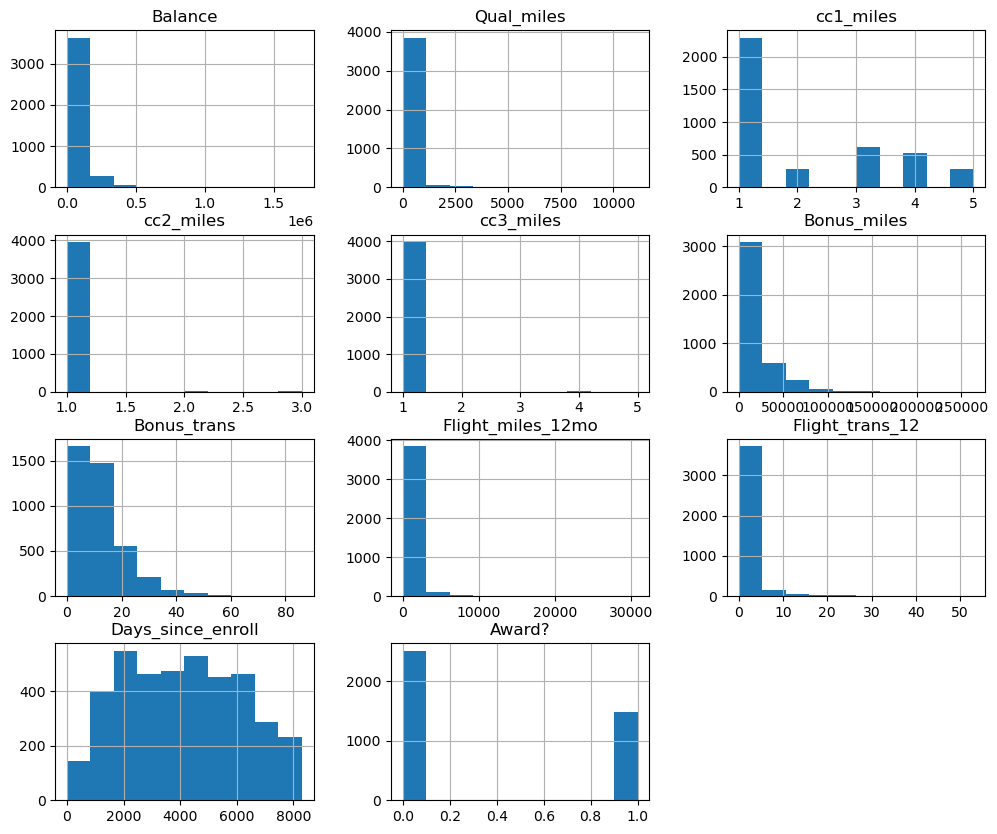

In [11]:
## Distribution plots..
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize = (12, 10))
plt.show()

In [12]:
## The histogram plots shows that most of the variables in the dataset are highly right skewed..
## meaning that a large number of customers have lower values while only a few customers have very high values..

## The variables Balance, Bonus_miles and Flight_miles_12mo show strong skewness with a few extreme high values..
## this indicates the presence of high value customers who travel frequently or accumulate larger miles..

## The variable cc1_miles,cc2_miles and cc3_miles are discrete in nature  and mostly concetrated in lower categories, 
## indicating that most customers falls into lower mileage categories..

## The Days_since_enroll feature apppears to be more uniformly distributed compared to other variables..
## this suggests that customers have been enrolled over wide range of time periods..

## The Award? variable is binary showing two distinct categories (0, 1) indicating whether a customer received an award or not..

## Overall the dataset shows significant variation in customer behavior with a majority of customers having lower activity levels..
## a small group of highly active customers which suggets the presence of potential clusters..

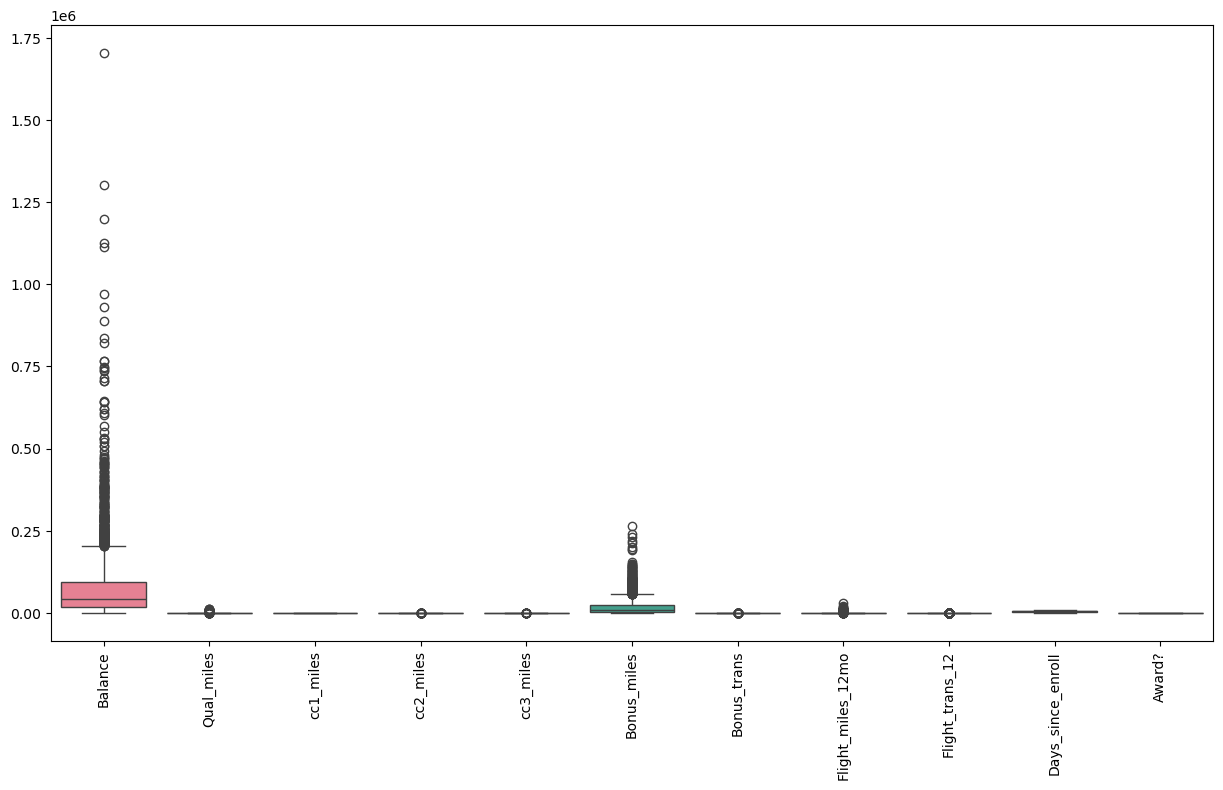

In [13]:
## Boxplots for outlier detection..
plt.figure(figsize = (15, 8))
sns.boxplot(data = df)
plt.xticks(rotation = 90)
plt.show()

In [14]:
## The Boxplots indicates the presence of several outliers in feature such as Balance, Bonus_miles and Flight_miles_12mo..
## These outliers represents customers with unusually high actvity levels which might form seperate clusters..

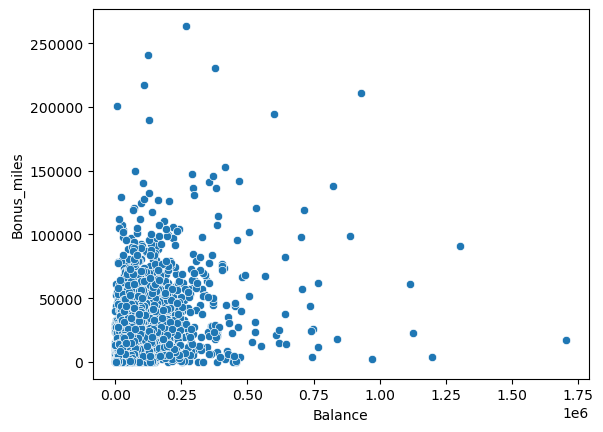

In [15]:
## Scatter plot..
sns.scatterplot(x = "Balance", y = "Bonus_miles", data = df)
plt.show()

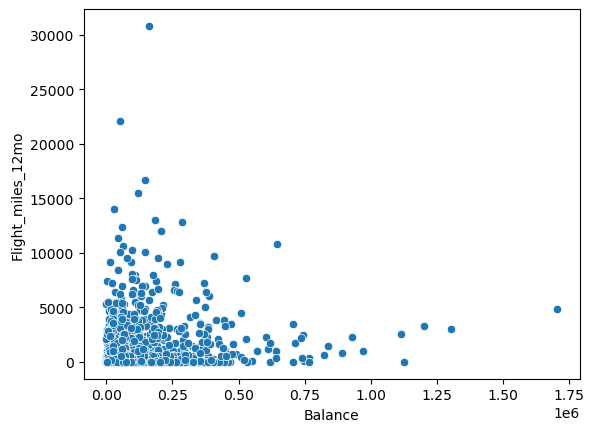

In [16]:
sns.scatterplot(x = "Balance", y = "Flight_miles_12mo", data = df)
plt.show()

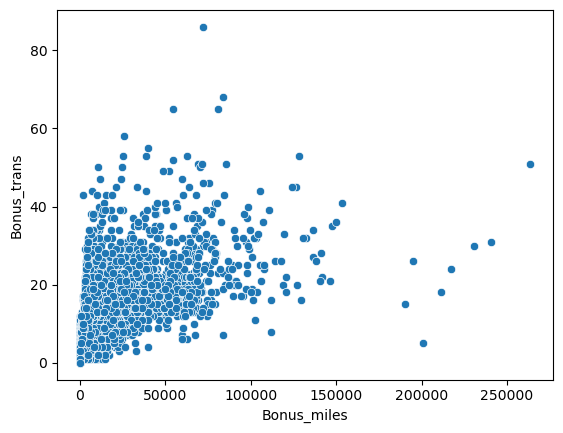

In [17]:
sns.scatterplot(x = "Bonus_miles", y = "Bonus_trans", data = df)
plt.show()

In [18]:
## The Scatter plot show that there is no clear linear pattern between variables but some grouping tendencies can be seen.. 
## Certain customers have high balances and high bonus miles while other have low values, it shows potential clusters..

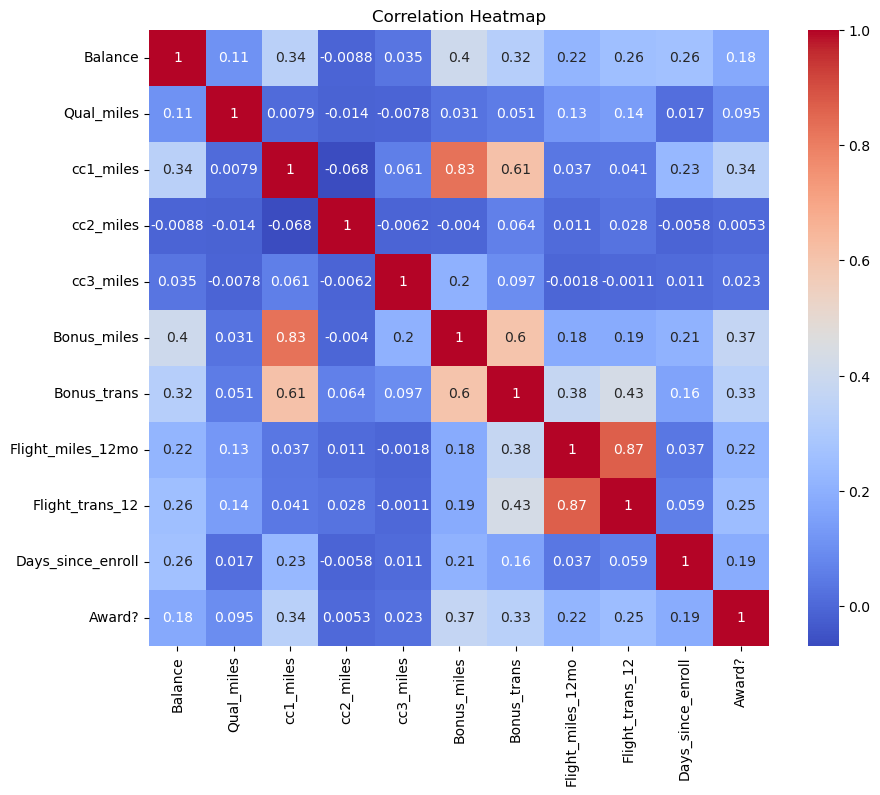

In [19]:
## Correlation Heatmap.. 
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
## The correlation heatmap shows that most of the variables have low correlation (around 0.3 or less)..
## This shows that features are largely indepenedent and capture different aspects of the customer..

## However few feture pairs show moderate to strong correlations..
## For example, Bonus_miles and cc1_miles (0.83), and Flight_trans_12 and Flight_miles_12mo (0.87) are having strong positive correlation..
## This shows that customers who can earn more also tend to have more transactions in those categories..

## Similarly Bonus_miles and Bonus_trans (0.6) and Bonus_trans and cc1_miles (0.61) show moderate correlation..
## This indicates some level of connection between overall acount balance and reward activity..

## Overall most of the features are weakly correlated, the presence of few strongly correlated variables suggests that certain customer behavior are closely related..
## This information is  useful for clustering as it might influence  how group formed..

### Implementing Clustering Algorithms

### Cluster Analysis and Interpretation

### Visualization

#### K-Means Clustering..

In [21]:
from sklearn.cluster import KMeans

In [22]:
## Elbow Method.. find optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

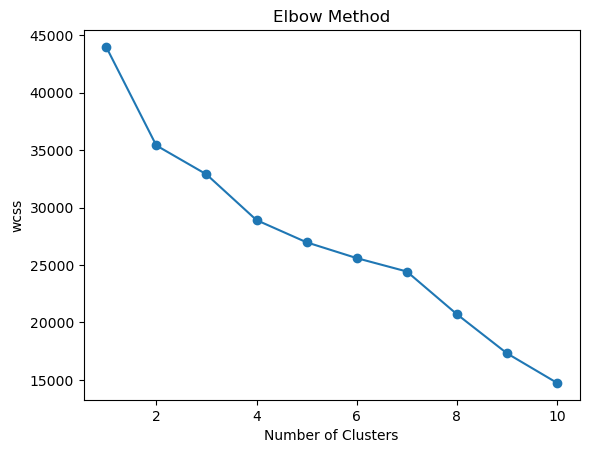

In [23]:
plt.plot(range(1, 11), wcss, marker = "o")
plt.xlabel("Number of Clusters")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

In [24]:
## The elbow method graph shows a sharp decrease in wcss from k = 1 to k = 4, after which rate of decrease becomes more gradual..
## This indicates that adding more clusters beyonds this point does not significantly reduce the within-cluster sum of squares..
## The elbow point appears around k = 4 suggesting that 4 clusters is an optimal choice for this dataset..
## The graph is not very sharp elbow type, but the best logical bend is at k = 4..
## even though the curve drops again around k = 8, but choosing it wil probably cause overfitting.. 

In [25]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df["KMeans_cluster"] = kmeans_labels

In [26]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2
1,19244,0,1,1,1,215,2,0,0,6968,0,2
2,41354,0,1,1,1,4123,4,0,0,7034,0,2
3,14776,0,1,1,1,500,1,0,0,6952,0,2
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1


In [27]:
## Cluster profiling..
df.groupby("KMeans_cluster").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_cluster,,,,,,,,,,,
0,193291.147436,795.455128,2.179487,1.038462,1.000000,32292.288462,27.628205,5530.230769,16.211538,4688.070513,0.820513
1,122119.899548,151.724887,3.885068,1.002715,1.043439,43772.394570,19.398190,366.520362,1.087783,4777.394570,0.687783
2,59693.586570,112.733010,1.372168,1.031553,1.000809,6311.116505,8.456311,258.830097,0.806634,5744.810680,0.296117
3,36920.458056,96.690413,1.269640,1.006658,1.000000,4897.208389,6.790280,167.861518,0.509321,2236.466711,0.151132


In [28]:
## The KMeans clustering divided the customers into 4 distinct groups based on their behavior and activity levels..

## Cluster 0 (High value customers)
## Customer in this have very high balance, high bonus miles and highest number of flight miles and transactions..
## They also show a high value in the award variable indicating that most of them have received rewards..
## These customers represent high value and frequent flyers who are highly engaged with airline..

## Cluster 1 (High Bonus but low Flight activity)
## In this customers have high bonus miles and relatively high balance, but very low flight miles and transactions..
## This means they earn rewards through non flight activities (like credit cards) rather than actual travel..
## They can be considered reward focused customers with low frequency travels..

## Cluster 2 (Moderate customers)
## Customers in this show moderate balance, moderate bonus miles and low flight activity..
## Their values are neither very high nor very low compared to other clusters..
## They can be considered average or regular customers with moderate engagement..


## Cluster 3 (Low value customers)
## They have the lowest balance, lowest bonus miles and minimal flight transactions..
## They also have the lowest value for the Award variable. 
## These customers represents low engagement or inactive customers..


## The cluster results clearly separate customers into different segments such as high value frequent flyers, reward based users, moderate users and low value users..
## This segmentation can help the airline design targeted marketing stratergies for different customers groups..

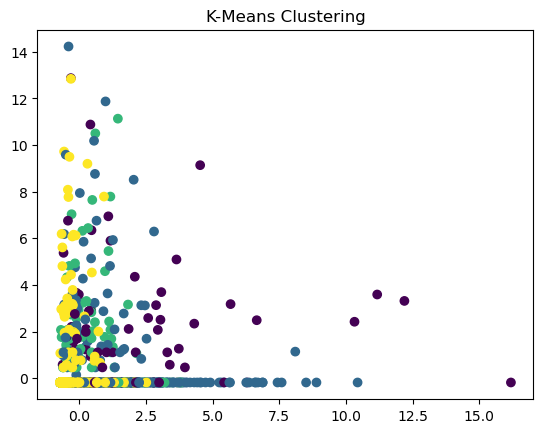

In [29]:
## Visualisation..
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = kmeans_labels)
plt.title("K-Means Clustering")
plt.show()

In [30]:
## The scatter plot shows the clustering results obtained from the KMeans algorithm where the different color represents different segments..
## The data points are not  very clearly seperated and there is a significant overlap between clusters..
## This means that the dataset does not have very distinct boundaries between customer groups..
## However some grouping patterns can still be observed..a large number of customers are concentrated in the lower range of values..
## This shows that most customer have lower activity levels..
## A few data points are spread far from the main cluster, representing high value or outlier customers..
## The presence of overlapping clusters indicates that while KMeans has grouped the data, the seperation between clusters is not very strong.. 
## This is common in real world dataset to be honest as far as i researched about them..
## Overall the visualisation shows that KMeans had identified segments but the clusters are not sharply defined indicating moderate clustering performance..

#### Hierarchical clustering

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [32]:
## Linkage matrix
linkage_methods = ["ward","complete", "average", "single"]

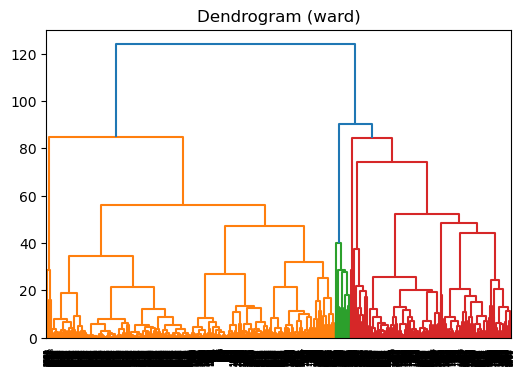

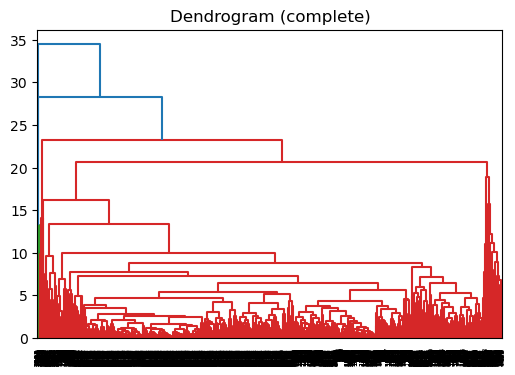

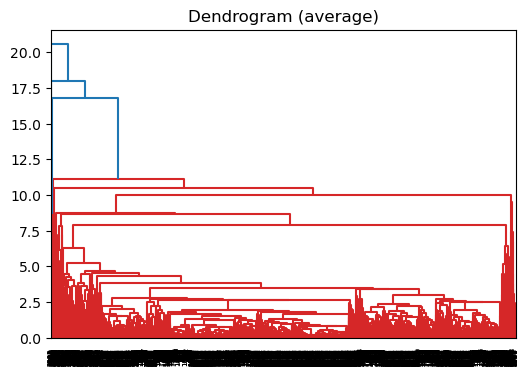

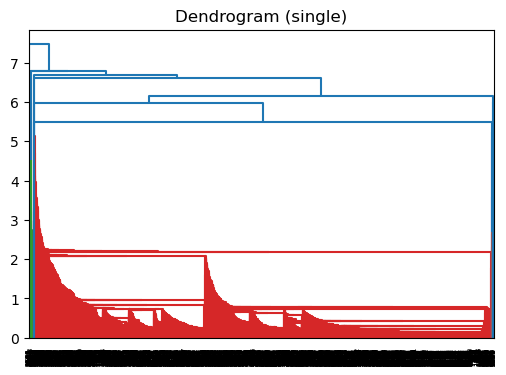

In [33]:
## plot dendrogram
for i in linkage_methods:
    Z = linkage(scaled_data, method = i)
    plt.figure(figsize = (6, 4))
    dendrogram(Z)
    plt.title(f"Dendrogram ({i})")
    plt.show()

In [34]:
## Different linkage methods were tested  and ward linkage is the best with clear and better cluster seperation..

In [35]:
## WARD linkage dendrogram (selected)..
## now we decide on optimal number of clusters..
## From the dendrogram a significant vertical distance is observed at higher levels in ward linkage..
## This indicates strong seperation between cluster at that point..
## By cutting the dendrogram at an appropriate distance (around 70-80), 4 clusters are identified as the optimal number..
## This choice balances cluster seperation and interpretability.. 

In [36]:
## Agglomerative clustering 
from sklearn.cluster import AgglomerativeClustering

hierarchical_c = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
hierarchical_c_labels = hierarchical_c.fit_predict(scaled_data)

In [37]:
## Add this to data frame as well.. 
df["HC_cluster"] = hierarchical_c_labels

In [38]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster,HC_cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,2,1
1,19244,0,1,1,1,215,2,0,0,6968,0,2,1
2,41354,0,1,1,1,4123,4,0,0,7034,0,2,1
3,14776,0,1,1,1,500,1,0,0,6952,0,2,1
4,97752,0,4,1,1,43300,26,2077,4,6935,1,1,0


In [39]:
## Cluster profiling 
df.groupby("HC_cluster").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster
HC_cluster,,,,,,,,,,,,
0,116314.450725,363.839130,3.498551,1.000000,1.035507,37150.356522,18.066667,377.000000,1.150000,4696.888406,0.663043,1.255797
1,46329.336877,9.028618,1.244072,1.000000,1.000000,4868.112428,6.907604,214.812756,0.673753,3769.337694,0.184383,2.552330
2,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846,0.176923
3,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349,1.953488


In [40]:
## Cluster 2: High value customers segment..
## This cluster got highest Balance, very high Bonus miles and Bonus transactions, Highest Flight miles and Flight transcations...'
## High Award rate.. these are frequent and premium customers..Highly engaged with airlines services.. and actively use rewards and benifits..

## Cluster 0: Moderate loyality, High value customer..
## High balance, Good Bonus miles, moderate Transations, Low flight activity in comparison with cluster 2, Good Award rate..
## Customers are loyal but less frequent flyers, Likely use credit card benifts more than flights

## Cluster 3: Moderate customers..
## Medium Balance, moderate Bonus miles, low flight activity, moderate Award rate..
## Average customers with moderate engagement, not highly active in flight or rewards..

## Cluster 1: Low value customers..least valuable segment..
## Lowest Balance, very low Bonus miles, minimal Flight activity, very low Award rate..
## Inactive or low engagement customers, rarely use airline services or rewards..

## Hierarchical clustering successfully segmented customers into 4 distinct groups ranging from high value frequent flyers to low activity customers..
## The results are consistent with K-Means clustering, indicating stble and meaningful customer segementation..

## The clustering shows that variable like Bonus miles, Flight activity and Balance play a key role in differenciating customer segments..

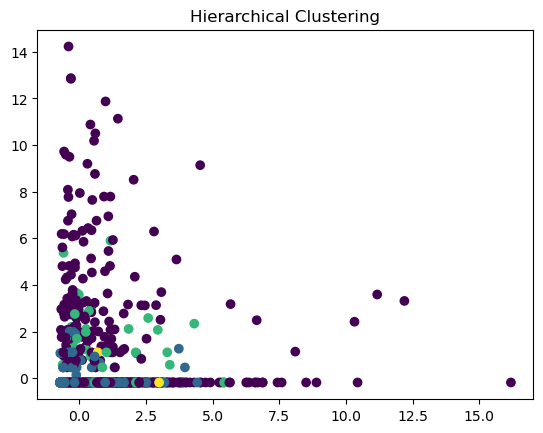

In [41]:
## Visualization for Hierarchical clustering..
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = hierarchical_c_labels)
plt.title("Hierarchical Clustering")
plt.show()

In [42]:
## The scatter plot show that most data points are concentrated in the dense region at lower feature values forming the primary clusters..

## A few clusters are distinguishable with moderate seperation while some overlap is still present..
## indicating that the dataset does not have very clearly defined boundaries..

## Additionally some data points are spread far from the main cluster groups representing potential outliers..

## Overall it provides relatively better seperation compared to K-Means but some overlap still exists..

#### DBSCAN 

In [43]:
## Group data based on density, can detect outliers (noice points), and no need to specify number of clusters..

In [44]:
## import
from sklearn.cluster import DBSCAN

In [45]:
## applying DBSCAN
dbscan = DBSCAN(eps = 1.5, min_samples = 5)
db_labels = dbscan.fit_predict(scaled_data)

In [46]:
## Add this to dataframe..
df["DBSCAN_cluster"] = db_labels

In [47]:
df.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?', 'KMeans_cluster', 'HC_cluster',
       'DBSCAN_cluster'],
      dtype='object')

In [48]:
df["DBSCAN_cluster"].value_counts()

## (-1) basically represents outliers here.. 
## A significant number of data points are labeled as -1..
## DBSCAN is effectively identifying outliers in the dataset.. these customers behave very differently from normal patterns..
##  This is an advantage over K-Means and Hierarchical clustering..
## Cluster 0 and 1 have large number of data points.. 2,3 and 4 have very few observations..
## It means DBSCAN is forming few dense clusters.. smaller cluster represent rare customer segments..

DBSCAN_cluster
 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64

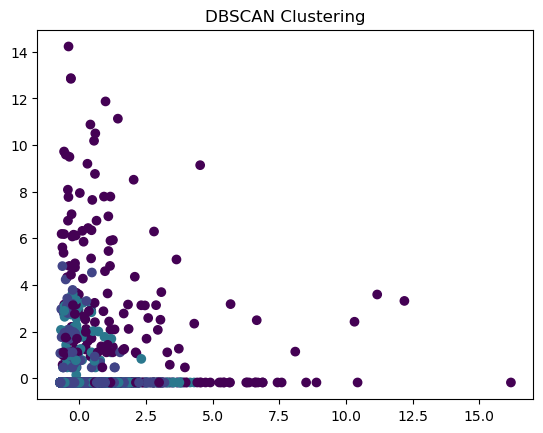

In [49]:
## Visualization for DBSCAN
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = db_labels)
plt.title("DBSCAN Clustering")
plt.show()

In [50]:
## Most points are densely packed near origin, some scatter points are far away (outliers)..
## Clusters are not clearly seperable..
## DBSCAN struggels to form clean clusters due to uneven density, presence of significant amount of outliers..

In [51]:
## Compared to K-Means and Hierarchical, DBSCAN detects outliers but poor cluster seperation here..
## K-Means has better structured clusters
## In case of Hierarchical, clear grouping is there via dendrogram..

In [52]:
## Lets try Tuning Eps for better performance of DBSCAN
eps = [0.5, 0.8, 1.0, 2.0]
for i in eps:
    dbscan = DBSCAN(eps = i, min_samples = 5)
    labels = dbscan.fit_predict(scaled_data)

    print("Eps", i)
    print("Clusters", len(set(labels)) - (1 if -1 in labels else 0))
    print("Noise points", list(labels).count(-1))
    print("-"*30)

Eps 0.5
Clusters 16
Noise points 1413
------------------------------
Eps 0.8
Clusters 8
Noise points 776
------------------------------
Eps 1.0
Clusters 6
Noise points 554
------------------------------
Eps 2.0
Clusters 6
Noise points 179
------------------------------


In [53]:
## it can be seen that at lower eps values the number of noice points is very high..indicating overly strict clustering..
## we will choose eps = 1.0, because it has balanced number of clusters, acceptable noice..
## not too strict not too loose..

## Why not eps = 2? because it has very low noice, same cluster as eps = 1.0.. too relaxed, might merge different clusters.. 
## Risk of loosing meaningful insights..

In [54]:
dbscan = DBSCAN(eps = 1.0, min_samples = 5)
db_labels_final = dbscan.fit_predict(scaled_data)

In [55]:
df["DBSCAN_cluster_final"] = db_labels_final

In [56]:
## Cluster profiling for DBSCAN 
df.groupby("DBSCAN_cluster_final").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_cluster,HC_cluster,DBSCAN_cluster
DBSCAN_cluster_final,,,,,,,,,,,,,,
-1,184010.198556,947.731047,2.754513,1.059567,1.088448,40265.904332,22.375451,2194.700361,6.324910,4757.777978,0.691336,1.079422,0.687726,-0.231047
0,53298.132385,4.695558,1.658042,1.000000,1.000000,9046.818025,8.468305,133.003881,0.422165,3799.103924,0.000000,2.404053,0.854248,0.000000
1,61334.918573,9.830741,2.591034,1.000000,1.000000,22886.188472,12.860018,286.425435,0.912168,4503.006404,1.000000,1.671546,0.380604,1.000000
2,34806.538462,0.000000,1.000000,2.000000,1.000000,8389.769231,12.000000,19.230769,0.153846,3186.153846,0.000000,2.538462,3.000000,2.000000
3,38616.166667,0.000000,1.000000,3.000000,1.000000,14966.833333,14.000000,41.666667,0.166667,3835.666667,0.000000,2.000000,3.000000,3.000000
4,164883.400000,1471.600000,1.000000,1.000000,1.000000,8472.800000,5.000000,300.000000,1.400000,4173.400000,1.000000,2.200000,0.000000,1.000000
5,27113.888889,2475.444444,1.000000,1.000000,1.000000,2169.111111,4.555556,44.444444,0.333333,1900.111111,0.000000,3.000000,0.000000,0.000000


In [57]:
## DBSCAN identified multiple clusters along with one noice cluster (-1), which contain significant number of data points..
## The noice cluster represents customer with very high values in features like Balance, Bonus miles, and Flight activity..
## This indicates that these are outliers..

## Some clusters like 0 and 2,consists of customers with low Balance, low Flight miles and fewer Transactions.. 
## This represents low engagements or inactive customers..

## Cluster 1 shows relatively moderate activity, with average values across most feature.. indicating medium engagement customers..

## Smaller clusters like (3, 4 and 5), represent those with slightly higher Bonus miles, or specific card usage patterns or limited travel patterns..

## Overall DBSCAN successfully seperates High value outliers and low and medium engagement customers groups..

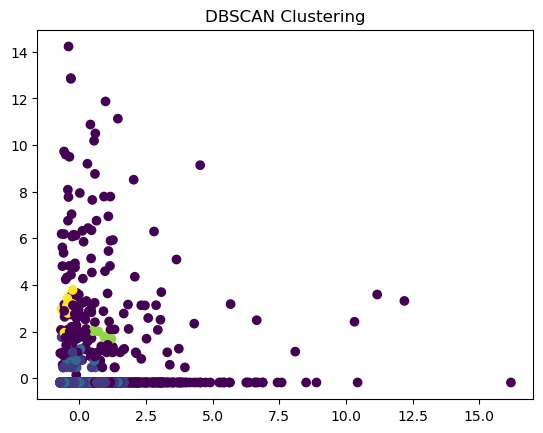

In [58]:
## Visualization for DBSCAN (eps = 1)
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c = db_labels_final)
plt.title("DBSCAN Clustering")
plt.show()

In [59]:
## The scatter plot shows that most data points are densely concentrated near the lower range of feature values, forming main clusters..

## A large number of points are marked as noise (outliers), which are spread across the plot, especially in higher value regions..
## This indicates the presence of customer with unusual or extreme behaviour..

## The cluster that are not very well seperated and show overlap, suggesting that the datasethas varying density and no clear boundaries between groups..

## Compared to other clustering methods DBSCAN effectively identifies outliers and dense region but does not produce very clearly seperated clusters..

## Overall the visualization confirms that DBSCAN is suitable for detecting irregular patterns and outliers, even though cluster seperation is moderate..

### Evaluation and Performance Metrics

#### Silhoutte Score

In [60]:
from sklearn.metrics import silhouette_score

In [61]:
## KMeans
sil_kmeans = silhouette_score(scaled_data, kmeans_labels)

## Hierarchical
sil_hc = silhouette_score(scaled_data, hierarchical_c_labels)

## DBSCAN (ignore noice points = -1)
sil_dbscan = silhouette_score(scaled_data[db_labels_final != -1], db_labels_final[db_labels_final != -1])

print("KMeans Silhouette Score:", sil_kmeans)
print("Hierarchical Silhouette Score:", sil_hc)
print("DBSCAN Silhouette Score:", sil_dbscan)

KMeans Silhouette Score: 0.19071186813310886
Hierarchical Silhouette Score: 0.30814152852022786
DBSCAN Silhouette Score: 0.281707334271592


In [62]:
## The Silhouette score is used to evaluate teh quality of clustering where values closer to 1 indicates well seperated clusters..
## The values closer to 0 indicates overlapping clusters..

## K-Means achieved a Silhouette score of 0.19 indicating relatively weak cluster seperation and higher overlap between clusters..

## Hierarchical clustering achieved a Silhouette score of 0.31 which is the highest among the three methods indicating better defined and more distinct clusters..

## DBSCAN achieved a Silhouette score of 0.28 (after removing noice points)..it shows moderate cluster quality and reasonable seperation..

## Based on these results Hierarchical clustering performs better in terms of cluster seperation.. 

In [63]:
## Final conclusion..

## All three clustering algorithm were applied and evaluated on the dataset..

##K-Means produced clusters but showed weaker seperation (least Silhouette Score)..

## Hierarchical clustering provided the best performance with highest Silhouette Score and meaningful cluster structure..
## hence making it the most suitable method for this dataset..

## DBSCAN was effective in identifying noice points and outliers which is an advantage over other methods
## but the cluster seperation was slightly lower than Hierarchical clustering..

## Overall, Hierarchical clustering is the best performing algorithm for this dataset..
## DBSCAN is useful for detecting outliers,,

In [64]:
df.columns

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?', 'KMeans_cluster', 'HC_cluster',
       'DBSCAN_cluster', 'DBSCAN_cluster_final'],
      dtype='object')